# Q10.
```{admonition}
:class: note
We now use boosting to predict `Salary` in the `Hitters` data set.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [4]:
import seaborn as sns

In [ ]:
hitters = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/Hitters.csv')

In [6]:
hitters.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [7]:
hitters.sample(3)

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
52,19,7,0,1,2,1,4,41,13,1,3,4,4,A,E,0,0,0,NaN,A
285,281,76,3,42,25,20,8,2658,657,48,324,300,179,A,E,106,144,7,341.667,A
96,565,148,24,90,104,77,14,7287,2083,305,1135,1234,791,A,E,292,9,5,1861.460,A


## (a)
```{admonition}
:class: note
Remove the observations for whom the salary information is unknown, and then log-transform the salaries.

In [8]:
hitters = hitters[hitters['Salary'].notna()]
hitters['Salary'] = np.log(hitters['Salary'])

## (b)
```{admonition}
:class: note
Create a training set consisting of the first 200 observations, and a test set consisting of the remaining observations.

In [9]:
hitters[['League','NewLeague']] = hitters[['League','NewLeague']] == 'N'
hitters['Division'] = hitters['Division'] == 'W'

In [10]:
X_train, X_test, y_train, y_test = train_test_split(hitters.drop(columns='Salary'),hitters['Salary'],random_state=1728,train_size=200,shuffle=True)
feature_count = X_train.shape[1]
features = X_train.columns

## (c+d)
```{admonition}
:class: note
Perform boosting on the training set with $1,000$ trees for a range of values of the shrinkage parameter $\lambda$. Produce a plot with different shrinkage values on the $x$-axis and the corresponding training set MSE on the $y$-axis. Produce a plot with different shrinkage values on the $x$-axis and the corresponding test set MSE on the $y$-axis.

In [11]:
from joblib import Parallel, delayed

In [12]:
alphas = np.logspace(-6,-1,50)

def eval_alpha(a):
    gbr_a = GradientBoostingRegressor(learning_rate=a,n_estimators=1000)
    gbr_a.fit(X_train,y_train)
    train_error = mean_squared_error(gbr_a.predict(X_train),y_train)
    test_error = mean_squared_error(gbr_a.predict(X_test),y_test)
    return train_error, test_error

res = Parallel(n_jobs=-1)(delayed(eval_alpha)(a) for a in alphas)

In [13]:
train_error, test_error = map(np.array,zip(*res))

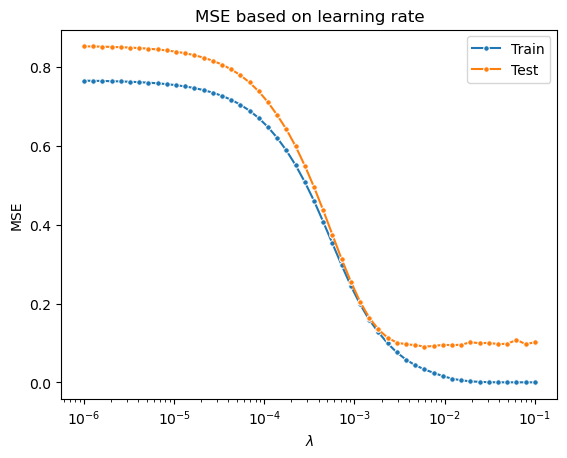

In [14]:
ax = plt.subplot()
sns.lineplot(x=alphas,y=train_error,marker='o',markersize=4,label='Train')
sns.lineplot(x=alphas,y=test_error,marker='o',markersize=4,label='Test')
ax.set_xticks(alphas[::5])
ax.set_xscale('log')
ax.set_ylabel('MSE')
ax.set_xlabel(r'$\lambda$')
ax.set_title('MSE based on learning rate')
plt.show()

## (e)
```{admonition}
:class: note
Compare the test MSE of boosting to the test MSE that results from applying two of the regression approaches seen in Chapters 3 and 6.

In [15]:
lr = LinearRegression()
lr.fit(X_train,y_train)
lr_mse = mean_squared_error(lr.predict(X_test),y_test)

In [16]:
pipe1 = Pipeline(
    [
        ('scale',StandardScaler()),('lasso',Lasso(max_iter=10000))
    ]
)

grid1 = GridSearchCV(pipe1,{'lasso__alpha':np.logspace(-4,2)},scoring='neg_mean_squared_error')
grid1.fit(X_train,y_train)
lasso_mse = mean_squared_error(grid1.predict(X_test),y_test)

In [17]:
pipe2 = Pipeline(
    [
        ('scale',StandardScaler()),('ridge',Ridge(max_iter=10000))
    ]
)

grid2 = GridSearchCV(pipe2,{'ridge__alpha':np.logspace(-4,2)},scoring='neg_mean_squared_error')
grid2.fit(X_train,y_train)
ridge_mse = mean_squared_error(grid2.predict(X_test),y_test)

In [18]:
best_boost_mse = test_error.min()
print(f'Boosting MSE: {best_boost_mse:.4f}')
print(f'Multilinear MSE: {lr_mse:.4f}')
print(f'Ridge MSE: {lasso_mse:.4f}')
print(f'Lasso MSE: {ridge_mse:.4f}')

Boosting MSE: 0.0908
Multilinear MSE: 0.3421
Ridge MSE: 0.3192
Lasso MSE: 0.3205


## (f)
```{admonition}
:class: note
Which variables appear to be the most important predictors in the boosted model?

In [19]:
gbrb = GradientBoostingRegressor(alpha=0.01)
gbrb.fit(X_train,y_train)
df = pd.DataFrame({'Importance':gbrb.feature_importances_},index=features)
print(df.sort_values(by='Importance',ascending=False))

           Importance
CAtBat       0.399558
CHits        0.210822
CRBI         0.059335
Walks        0.048852
CWalks       0.044157
AtBat        0.038923
Hits         0.035495
CRuns        0.034550
Years        0.030545
CHmRun       0.029818
RBI          0.014810
Errors       0.013913
PutOuts      0.013436
Runs         0.009459
HmRun        0.007898
Assists      0.006677
NewLeague    0.001375
Division     0.000378
League       0.000000


## (g)
```{admonition}
:class: note
Now apply bagging to the training set. What is the test set MSE for this approach?

In [20]:
rfrb = RandomForestRegressor(max_features=feature_count,n_jobs=-1)
rfrb.fit(X_train,y_train)

test_MSE_bagging = mean_squared_error(rfrb.predict(X_test),y_test)
print(f'Bagging MSE is {test_MSE_bagging:.4f}')

Bagging MSE is 0.0960
